## **SIMULATING AN HAMILTONIAN EXPRESSED IN THE BAISIS OF PAULI MATRICES**

contoh pada sistem heisenberg spin chain 3-site

In [1]:
!pip install qiskit --quiet
!pip install qiskit_ibm_runtime --quiet

import numpy as np
import matplotlib.pyplot as plt
import scipy.linalg as LA
from qiskit import *
from qiskit.quantum_info import Operator
from qiskit_ibm_runtime import QiskitRuntimeService, SamplerV2 as Sampler, Batch

In [2]:
#Heisenberg Hamiltonian for site n
from qiskit.quantum_info import SparsePauliOp

def get_hamiltonian_n_site_terms(n, coeff, n_qubits):
    XX_coeff = coeff[0]
    YY_coeff = coeff[1]
    ZZ_coeff = coeff[2]
    Z_coeff = coeff[3]

    XX_term =SparsePauliOp(("I" * n + "XX" + "I" * (n_qubits - 2 - n)))
    XX_term *= XX_coeff

    YY_term = SparsePauliOp(("I" * n + "YY" + "I" * (n_qubits - 2 - n)))
    YY_term *= YY_coeff

    ZZ_term = SparsePauliOp(("I" * n + "ZZ" + "I" * (n_qubits - 2 - n)))
    ZZ_term *= ZZ_coeff

    Z_term = SparsePauliOp(("I" * n + "Z" + "I" * (n_qubits - 1 - n)))
    Z_term *= Z_coeff

    return(XX_term + YY_term + ZZ_term + Z_term)

In [3]:
#Heisenberg Hamiltonian for N sites
def get_heisenberg_hamiltonian(n_qubits, coeff=None):
    #three qubits because for 2 we get H0 = 0
    assert n_qubits>=3

    if coeff==None:
        'setting default values for the coeefficients'
        coeff = [[1.0, 1.0, 1.0, 1.0] for i in range(n_qubits)]

    #even terms of the hamiltonian
    #summing over individual pair-wise element
    H_E = sum((get_hamiltonian_n_site_terms(i, coeff[i], n_qubits) for i in range(0, n_qubits-1, 2)))

    #odd terms of the hamiltonian
    #summing over individual pair-wise elements
    H_O = sum((get_hamiltonian_n_site_terms(i, coeff[i], n_qubits) for i in range(1, n_qubits-1, 2)))
    
    #adding final Z term at the N site
    final_term = SparsePauliOp("I" * (n_qubits - 1) + "Z")
    final_term *= coeff[n_qubits-1][3]

    if (n_qubits % 2) == 0:
        H_E += final_term
    else:
        H_O += final_term

    #returns the lis of the two sets of terms
    return [H_E, H_O]

In [4]:
#Heisenberg Hamiltonian 3 sites
num_q = 3

## XX YY ZZ, Z
ham_coeffs = ([[0.75/2, 0.75/2, 0.0, 0.65]] 
            + [[0.5, 0.5, 0.0, 1.0] 
            for i in range(num_q-1)])

spin_chain_hamiltonian = get_heisenberg_hamiltonian(num_q, ham_coeffs)

#print('Hamiltonian separated into even and odd components:')
#print(spin_chain_hamiltonian)
#print('Hamiltonian combining even and odd components:')
#print(sum(spin_chain_hamiltonian))

from IPython.display import display, Math

def to_latex(sparse_pauli_op):
    terms = []
    for pauli, coeff in zip(sparse_pauli_op.paulis, sparse_pauli_op.coeffs):
        c = round(coeff.real, 4)
        if abs(c) < 1e-10:
            continue

        label = pauli.to_label()
        pauli_parts = []
        for p in label:
            if p == 'I':
                pauli_parts.append(r"\mathbb{I}")
            else:
                pauli_parts.append(rf"\sigma_{{{p}}}")
        pauli_str = r" \otimes ".join(pauli_parts)

        if abs(c - 1.0) < 1e-10:
            terms.append(pauli_str)
        elif abs(c + 1.0) < 1e-10:
            terms.append(f"- {pauli_str}")
        else:
            terms.append(rf"{c} \cdot {pauli_str}")

    latex = r" + ".join(terms).replace(r"+ -", r"-")
    return rf"\hat{{H}} = {latex}"

H_total = sum(spin_chain_hamiltonian)
display(Math(to_latex(H_total)))

<IPython.core.display.Math object>

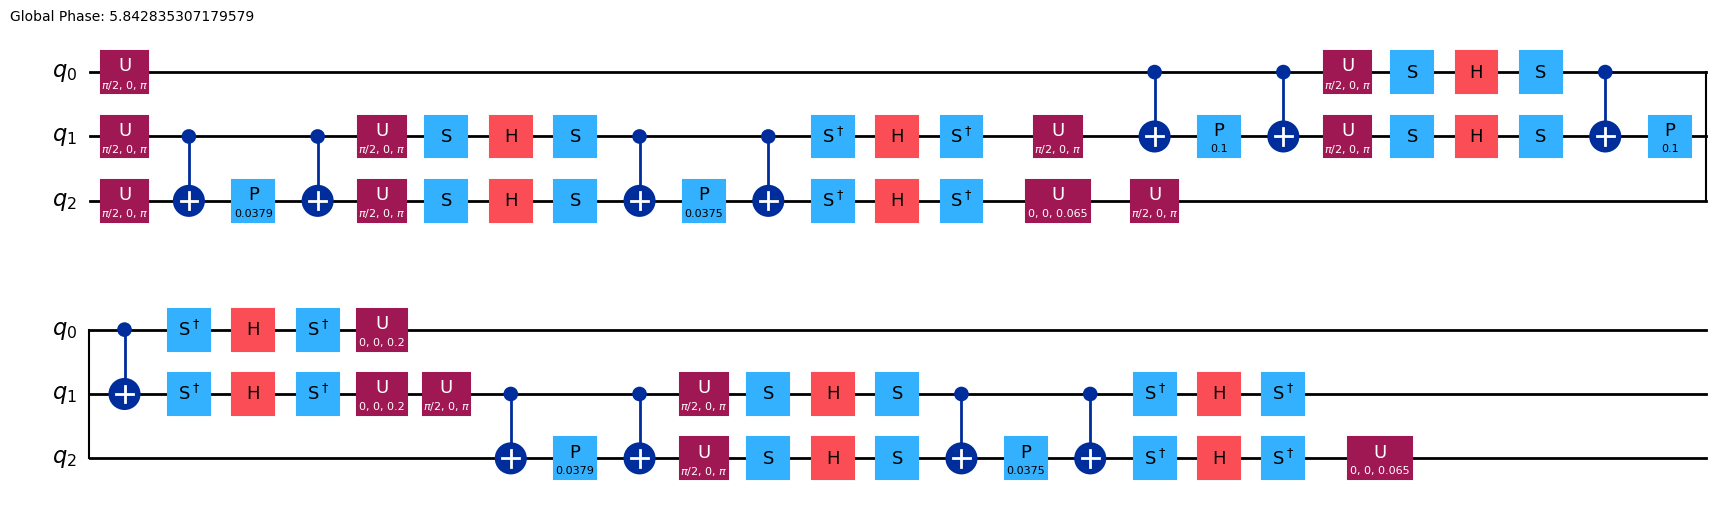

In [5]:
#trotterized time evolution operator
from qiskit.circuit.library import PauliEvolutionGate
from qiskit.synthesis import SuzukiTrotter
import matplotlib.pyplot as plt
from IPython.display import display

def get_time_evolution_operator(num_qubits, tau, trotter_steps, coeff=None):
    heisenberg_hamiltonian = get_heisenberg_hamiltonian(num_qubits, coeff)

    evo_op = PauliEvolutionGate(heisenberg_hamiltonian, tau, synthesis=SuzukiTrotter(order=2, reps=trotter_steps))
    return evo_op.definition

num_q = 3
evolution_timestep = 0.1
n_trotter_steps = 1
ham_coeffs = ([[0.757/2, 0.75/2, 0.0, 0.65]]
            + [[0.5, 0.5, 0.0, 1.0] 
            for i in range(num_q-1)])

time_evo_op = get_time_evolution_operator(num_qubits=num_q, tau=evolution_timestep, trotter_steps=n_trotter_steps, coeff=ham_coeffs)

fig = time_evo_op.decompose().decompose().draw('mpl')
display(fig)
plt.show()

In [6]:
#sorting terms by interaction order
import re
from itertools import groupby

def find_string_pattern(pattern, string):
    match_list=[]
    for m in re.finditer(pattern, string):
        match_list.append(m.start())
    return match_list

def sort_Pauli_by_symetry(ham):
    one_qubit_terms = []
    two_qubit_terms = []

    #separating the one-qubit from tqo-qubit terms
    for term in ham:
        matches = find_string_pattern('X|Y|Z', str(term.paulis[0]))
        pauli_string = term.paulis[0]
        coeff = np.real(term.coeffs[0])
        str_tag = pauli_string.to_label().replace('I', '')
        if len(matches) == 2:
            two_qubit_terms.append((pauli_string, coeff, matches, str_tag))
        elif len(matches) == 1:
            one_qubit_terms.append((pauli_string, coeff, matches, str_tag))

    #sorting the two-qubit terms according to index on which they act
    two_qubit_terms = sorted(two_qubit_terms, key=lambda x: x[2])

    #separating the even from the odd two-qubit terms
    even_two_qubit_terms = list(filter(lambda x: not x[2][0]%2, two_qubit_terms))
    odd_two_qubit_terms = list(filter(lambda x: x[2][0]%2, two_qubit_terms))

    even_two_qubit_terms = [list(v) for i, v in groupby(even_two_qubit_terms, lambda x: x[2][0])]
    odd_two_qubit_terms = [list(v) for i, v in groupby (odd_two_qubit_terms, lambda x: x[2][0])]

    return one_qubit_terms, even_two_qubit_terms, odd_two_qubit_terms

In [7]:
#circuit for exponensial of 1-qubit pauli term
def generate_circ_pattern_1qubit(circ, term, delta_t):
    coeff = 2 * term[1] * delta_t
    if term[3] == 'X':
        circ.rx(coeff, term[2])
    elif term[3] == 'Y':
        circ.ry(coeff, term[2])
    elif term[3]:
        circ.rz(coeff, term[2])

    return circ

In [8]:
#circuit fro exponensial of 2-qubit pauli term
def generate_circ_pattern_2qubit(circ, term, delta_t):
    #wires to which to appy the operation
    wires = term[0][2]

    #angles to parameterize the circuit, based on exponential argument
    if any('XX' in sublist for sublist in term):
        g_phi = ( 2 * (-1) * term[0][1] * delta_t - np.pi / 2)
    else:
        g_phi = - np.pi / 2

    if any('YY' in sublist for sublist in term):
        g_lambda = (np.pi/2 - 2 * (-1) * term[1][1] * delta_t)
    else:
        g_lambda = np.pi/2
    
    if any('ZZ' in sublist for sublist in term):
        g_theta = (np.pi/2 - 2 * (-1) * term[2][1] * delta_t)
    else:
        g_theta = np.pi/2

    # circuit
    circ.rz(-np.pi/2, wires[1])
    circ.cx(wires[1], wires[0])
    circ.rz(g_theta, wires[0])
    circ.ry(g_phi, wires[1])
    circ.cx(wires[0], wires[1])
    circ.ry(g_lambda, wires[1])
    circ.cx(wires[1], wires[0])
    circ.rz(np.pi/2, wires[0])
    return circ

In [9]:
#manual trotterization of propagator
def get_manual_Trotter(num_q, pauli_ops, timestep, n_trotter=1, trotter_type='basic', reverse_bits=True):
    #sort the pauli strings according to qubit number they affect and symmetry
    one_q, even_two_q, odd_two_q =sort_Pauli_by_symetry(pauli_ops)

    #scales the timstep according to the number of trotter steps
    timestep_even_two_q = timestep/n_trotter
    timestep_odd_two_q = timestep / n_trotter
    timestep_one_q = timestep / n_trotter

    #symmetric place 1/2 of one_q and odd_two_q before and after even_two_q
    if trotter_type == 'symmetric':
        timestep_odd_two_q /= 2
        timestep_one_q /= 2

    #contructs circuits fro each segment of the operators
    qc_odd_two_q, qc_even_two_q, qc_one_q = QuantumCircuit(num_q), QuantumCircuit(num_q), QuantumCircuit(num_q)
    
    for i in even_two_q:
        qc_even_two_q = generate_circ_pattern_2qubit(qc_even_two_q, i, timestep_even_two_q)

    for i in odd_two_q:
        qc_odd_two_q = generate_circ_pattern_2qubit(qc_odd_two_q, i, timestep_odd_two_q)

    for i in one_q:
        qc_one_q = generate_circ_pattern_1qubit(qc_one_q, i, timestep_one_q)

    #assembles the circuit for trotter decomposition of exponential
    qr = QuantumRegister(num_q)
    qc = QuantumCircuit(qr)
    if trotter_type == 'basic':
        qc = qc.compose(qc_even_two_q)
        qc = qc.compose(qc_odd_two_q)
        qc = qc.compose(qc_one_q)
    elif trotter_type == 'symmetric':
        qc = qc.compose(qc_one_q)
        qc = qc.compose(qc_odd_two_q)
        qc = qc.compose(qc_even_two_q)
        qc = qc.compose(qc_odd_two_q)
        qc = qc.compose(qc_one_q)

    #repeats the single_trotter circuit several times to match n_trotter
    for i in range(n_trotter-1):
        qc = qc.compose(qc)
    if reverse_bits:
        return qc.reverse_bits()
    else:
        return qc

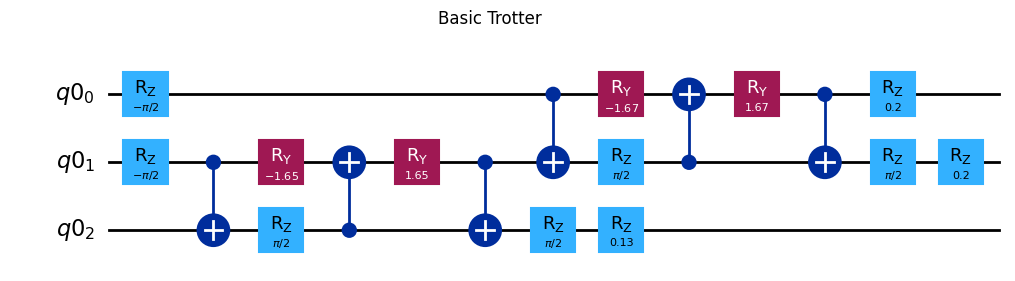

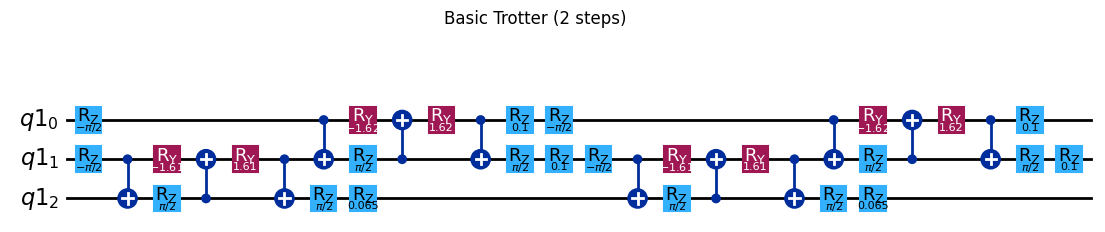

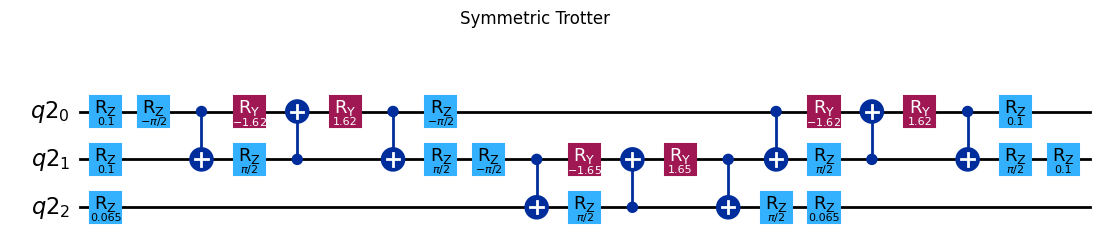

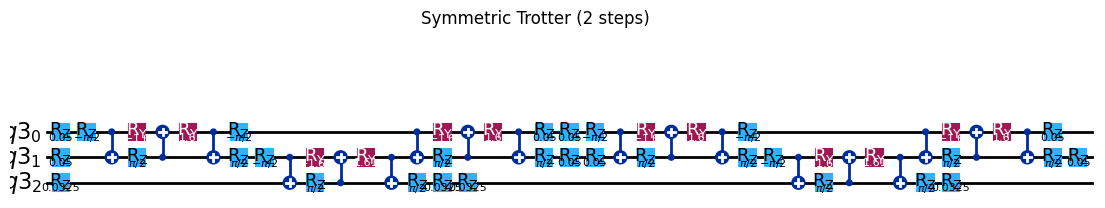

In [10]:
#manual trotter circuits
spin_chain_hamiltonian = get_heisenberg_hamiltonian(num_q, ham_coeffs)
spin_chain_hamiltonian = sum(spin_chain_hamiltonian)

#print(get_manual_Trotter(num_q, spin_chain_hamiltonian, 0.1).draw())
#print(get_manual_Trotter(num_q, spin_chain_hamiltonian, 0.1, n_trotter=2).draw())
#print(get_manual_Trotter(num_q, spin_chain_hamiltonian, 0.1, trotter_type='symmetric').draw())
#print(get_manual_Trotter(num_q, spin_chain_hamiltonian, 0.1, n_trotter=2, trotter_type='symmetric').draw())

circuits = [
    (get_manual_Trotter(num_q, spin_chain_hamiltonian, 0.1), "Basic Trotter"),
    (get_manual_Trotter(num_q, spin_chain_hamiltonian, 0.1, n_trotter=2), "Basic Trotter (2 steps)"),
    (get_manual_Trotter(num_q, spin_chain_hamiltonian, 0.1, trotter_type='symmetric'), "Symmetric Trotter"),
    (get_manual_Trotter(num_q, spin_chain_hamiltonian, 0.1, n_trotter=2, trotter_type='symmetric'), "Symmetric Trotter (2 steps)"),
]

for circ, title in circuits:
    fig = circ.draw('mpl', fold=-1, style='iqp')
    fig.suptitle(title, fontsize=12)
    fig.set_size_inches(14, 3)
    plt.tight_layout()
    display(fig)
    plt.close()

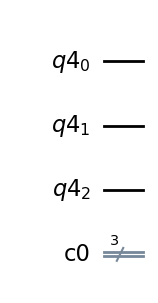

In [11]:
#inisialisasi quantum circuit dengan qiskit
qr = QuantumRegister(num_q)
cr = ClassicalRegister(num_q)
qc = QuantumCircuit(qr, cr)
qc.draw('mpl')

Statevector([0.+0.j, 0.+0.j, 0.+0.j, 0.+0.j, 0.+0.j, 0.+0.j, 1.+0.j,
             0.+0.j],
            dims=(2, 2, 2))


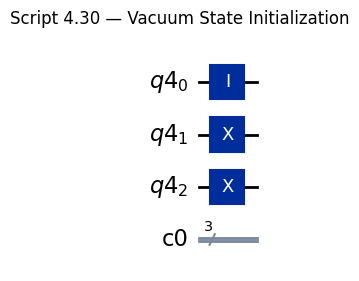

In [12]:
#quantum circuit for vacuum state initialization
from qiskit.quantum_info import Statevector

for qubit_idx in range(num_q):
    if qubit_idx == 0:
        #generate only one spin up at first qubit
        qc.id(qubit_idx)
    else:
        #make all other spins have the spin down state
        qc.x(qubit_idx)

qc_init_state = Statevector.from_instruction(qc)
print(qc_init_state)

fig = qc.draw('mpl', style='iqp', fold=-1)
fig.suptitle('Script 4.30 — Vacuum State Initialization', fontsize=12)
fig.set_size_inches(10, 3)
plt.tight_layout()
display(fig)
plt.close()

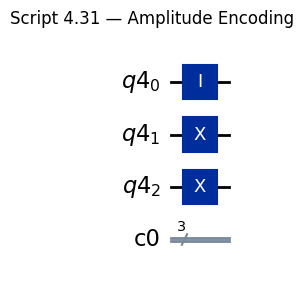

In [13]:
#inisialisasi keadaan: smplitudo encoding
qr_init = QuantumRegister(num_q)
qc_init = QuantumCircuit(qr_init)
qc_init.initialize('011', qr_init[:])
#qc.append(qc_init)

fig = qc.draw('mpl', style='iqp', fold=-1)
fig.suptitle('Script 4.31 — Amplitude Encoding', fontsize=12)
fig.set_size_inches(10, 3)
plt.tight_layout()
display(fig)
plt.close()

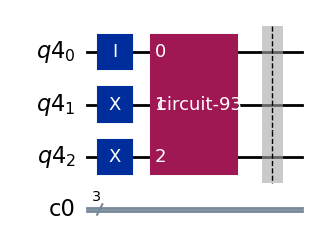

depth of the circuit is 2


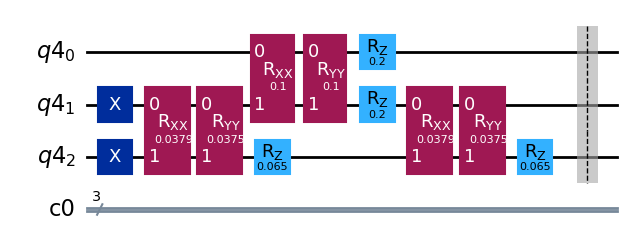

Depth of the circuit after transpilation is 9


In [14]:
#applying time evolution operator to circuit
from qiskit_aer import AerSimulator

time_evo_op = get_time_evolution_operator(num_qubits=num_q, tau=evolution_timestep, trotter_steps=n_trotter_steps, coeff=ham_coeffs)

#appending the hamiltonian evolution to circuit
qc.append(time_evo_op, list(range(num_q)))
qc.barrier()

fig1 = qc.draw('mpl', style='iqp', fold=1)
fig1.set_size_inches(10, 3)
plt.tight_layout()
display(fig1)
plt.close()

print('depth of the circuit is', qc.depth())

#transpilled circuit to statevector simulator
device = AerSimulator(method='statevector')
qct = transpile(qc, device, optimization_level=2)
qct.decompose().decompose()

fig2 = qct.draw('mpl', style='iqp', fold=1)
fig2.set_size_inches(10, 3)
display(fig2)
plt.close()

print('Depth of the circuit after transpilation is '
      f'{qct.depth()}')

In [15]:
#execution of quantum experiment
#Quantum circuit for propagation
from qiskit_aer import Aer

def qsolve_statevector(psin, qc):
    # Determining number of qubits from the length of the state vector
    d = int(np.log2(len(psin)))
    
    # Circuit preparation
    qre = QuantumRegister(d)
    circ = QuantumCircuit(qre)

    circ.initialize(psin, qre)
    circ.barrier()
    circ.append(qc, qre)
    circ.barrier()
    
    # Circuit execution
    device = Aer.get_backend('statevector_simulator')
    tcirc = transpile(circ, device)
    psin = device.run(tcirc).result()
    
    return psin.get_statevector()

[0 0 0 1 0 0 0 0]
Running dynamics step 0
Running dynamics step 1
Running dynamics step 2
Running dynamics step 3


/tmp/ipykernel_164658/3800465562.py:7: DeprecationWarning: The return type of saved statevectors has been changed from a `numpy.ndarray` to a `qiskit.quantum_info.Statevector` as of qiskit-aer 0.10. Accessing numpy array attributes is deprecated and will result in an error in a future release. To continue using saved result objects as arrays you can explicitly cast them using  `np.asarray(object)`.
  d = int(np.log2(len(psin)))


Running dynamics step 4
Running dynamics step 5
Running dynamics step 6
Running dynamics step 7
Running dynamics step 8
Running dynamics step 9
Running dynamics step 10
Running dynamics step 11
Running dynamics step 12
Running dynamics step 13
Running dynamics step 14
Running dynamics step 15
Running dynamics step 16
Running dynamics step 17
Running dynamics step 18
Running dynamics step 19
Running dynamics step 20
Running dynamics step 21
Running dynamics step 22
Running dynamics step 23
Running dynamics step 24
Running dynamics step 25
Running dynamics step 26
Running dynamics step 27
Running dynamics step 28
Running dynamics step 29
Running dynamics step 30
Running dynamics step 31
Running dynamics step 32
Running dynamics step 33
Running dynamics step 34
Running dynamics step 35
Running dynamics step 36
Running dynamics step 37
Running dynamics step 38
Running dynamics step 39
Running dynamics step 40
Running dynamics step 41
Running dynamics step 42
Running dynamics step 43
Runnin

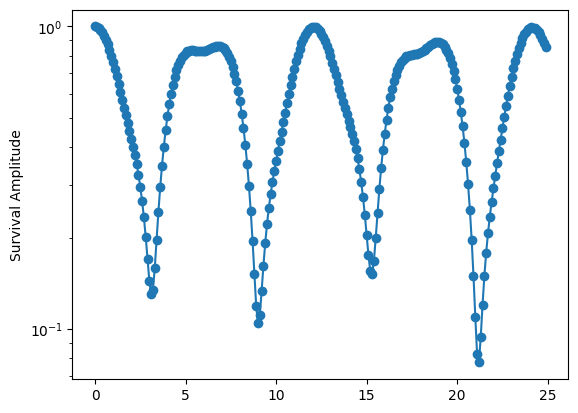

In [16]:
# Qubit basis states
zero_state = np.array([[1],[0]])
one_state = np.array([[0],[1]])

# For a 011 initial state prepare as follows
psin = zero_state # for the first spin

# iterates over the remaining spins, by performing Kronecker Product
for i in range(num_q-1):
    psin = np.kron(psin, one_state)

psin0 = psin.flatten()
print(psin0)

nsteps = 250
psin_list = []
psin_list.append(psin0)
correlation_list = []

# performs dynamical propagation by statevector re-initialization
for k in range(nsteps):
    print(f'Running dynamics step {k}')
    
    if k > 0:
        psin = qsolve_statevector(psin_list[-1], time_evo_op)
        
        # removes the last initial state to save memory
        psin_list.pop()

        # stores the new initial state
        psin_list.append(psin)
    correlation_list.append(np.vdot(psin_list[-1],psin0))

t = np.arange(0, evolution_timestep*(nsteps), evolution_timestep)

np.save(f'{num_q}_spin_chain_time', t)
sa_observable = np.abs(correlation_list)

np.save(f'{num_q}_spin_chain_SA_obs', sa_observable)

# plotting
plt.plot(t, sa_observable, '-o')
plt.ylabel('Survival Amplitude')
plt.yscale('log')
plt.show()